# Evaluation: Comparing Transformer, Snippet, and Hybrid Approaches

This notebook evaluates and compares the results of the three sentiment analysis approaches:
- DistilBERT baseline
- Snippet-based lexicon scoring
- Hybrid fusion (BERT + Snippet)

We use distribution analysis, company/year breakdowns, and error inspection to assess performance.

In [1]:
# 1. Setup
import pandas as pd
import matplotlib.pyplot as plt

# Load processed data
bert_df = pd.read_csv("../data/processed/distilbert_baseline.csv")
snippet_df = pd.read_csv("../data/processed/snippet_scores.csv")
hybrid_df = pd.read_csv("../data/processed/hybrid_scores.csv")

print("✅ Data loaded")
print("BERT rows:", bert_df.shape)
print("Snippet rows:", snippet_df.shape)
print("Hybrid rows:", hybrid_df.shape)

✅ Data loaded
BERT rows: (14166, 5)
Snippet rows: (9, 5)
Hybrid rows: (9, 7)


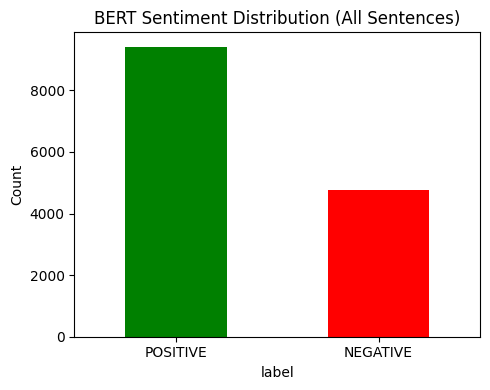

In [2]:
# 2. Distribution of BERT predictions
bert_counts = bert_df['label'].value_counts()

plt.figure(figsize=(5,4))
bert_counts.plot(kind='bar', color=['green','red'])
plt.title("BERT Sentiment Distribution (All Sentences)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/eval_bert_distribution.png", dpi=300)
plt.show()

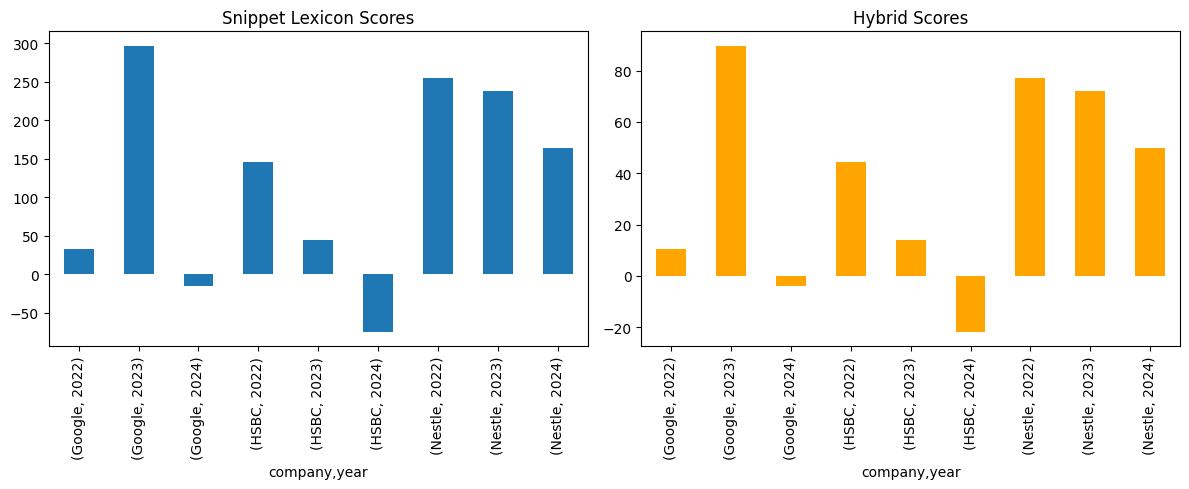

In [3]:
# 3. Document-level comparison (snippet vs hybrid)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

snippet_df.set_index(["company","year"])["score"].plot(kind="bar", ax=ax[0], title="Snippet Lexicon Scores")
hybrid_df.set_index(["company","year"])["hybrid_score"].plot(kind="bar", ax=ax[1], color="orange", title="Hybrid Scores")

plt.tight_layout()
plt.savefig("../images/eval_doc_comparison.png", dpi=300)
plt.show()

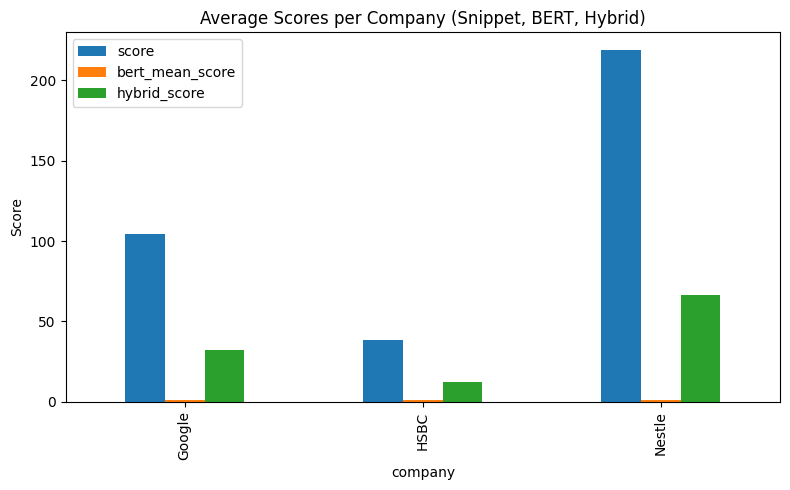

In [4]:
# 4. Company-level aggregation
company_means = hybrid_df.groupby("company")[["score","bert_mean_score","hybrid_score"]].mean()

company_means.plot(kind="bar", figsize=(8,5))
plt.title("Average Scores per Company (Snippet, BERT, Hybrid)")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("../images/eval_company_means.png", dpi=300)
plt.show()

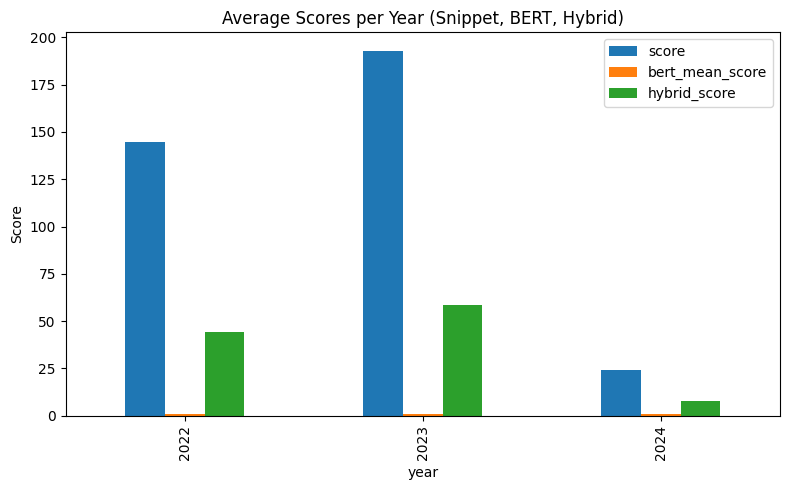

In [5]:
# 5. Year-level aggregation
year_means = hybrid_df.groupby("year")[["score","bert_mean_score","hybrid_score"]].mean()

year_means.plot(kind="bar", figsize=(8,5))
plt.title("Average Scores per Year (Snippet, BERT, Hybrid)")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("../images/eval_year_means.png", dpi=300)
plt.show()

In [6]:
# 6. Error inspection: sentences with potential misclassification
# For example: BERT says POSITIVE with high confidence but snippet gives strong negative
sample_errors = pd.merge(
    bert_df.groupby(["company","year"]).head(3), # pick a few sentences
    hybrid_df[["company","year","hybrid_score"]],
    on=["company","year"],
    how="left"
)

print("Sample inspection:")
print(sample_errors[["company","year","sentence","label","score","hybrid_score"]].head(10))

Sample inspection:
  company  year                                           sentence     label  \
0  Google  2022  environmental report table of contents 1 about...  POSITIVE   
1  Google  2022      it also mentions notable targets set in 2022.  POSITIVE   
2  Google  2022  this report outlines how we're driving positiv...  POSITIVE   
3  Google  2023  environmental report 2023 environmental report...  POSITIVE   
4  Google  2023  what's targets and progress summary 8 water st...  POSITIVE   
5  Google  2023  1 sustainability governance 76 reducing home e...  POSITIVE   
6  Google  2024  environmental report table of contents introdu...  POSITIVE   
7  Google  2024  throughout this report, we use the term nature...  POSITIVE   
8  Google  2024  this report • sustainability blog features dat...  POSITIVE   
9    HSBC  2022  environmental, social and governance review ou...  POSITIVE   

      score  hybrid_score  
0  0.902096     10.529122  
1  0.972656     10.529122  
2  0.999263     